# **Chebyshev**

## **Trabajo Semanal 3**

#### Autor: Keila Korj
#### Profesor: Mariano Llamedo Soria
#### Ayudante de TPs: David Moharos

## ***Resumen***

En este trabajo se hará el desarrollo del diseño e implementación de un filtro pasa altos por aproximación de *Chebyshev* a partir de la siguiente plantilla.

<figure style="text-align:center;">
    <img src="plantilla_HP.png" width="800">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 1. Plantilla pasa altos pedida
    </figcaption>
</figure>

Donde al normalizar por frecuencia quedaría: $fs= \frac{1}{4}$ y $fp=1$



### ***Introducción***

En primera instancia no podemos comenzar diseñando el filtro pasa altos, en su lugar debemos realizar un filtro pasa bajos por aproximación de *Chebyshev* de modo tal que al obtener la transferencia correspondiente aplicaremos la función transformación $f(s) = \frac{1}{s}$ para así obtener el filtro deseado.
Para ello debemos modificar la plantilla dada para que esta pertenezca a la de un filtro pasa bajos, por esa razón las frecuencias por la transformación $\frac{1}{w}$ sería:  $fs= 4$ y $fp=1$, igual modo las frecuancia angulares quedarían: $ws= 4$ y $wp=1$. Manteniendo el $\alpha_{min} = 30dB$ y el $\alpha_{max} = 0.5dB$

- El diseño de inicia buscando el $\varepsilon^{2}$ tal que:

  $$ \varepsilon^{2} = 10^{\frac{\alpha_{max}}{10}} -1 $$

  Dando como resultado:
  $$\varepsilon^{2} = 0.1220$$

- Luego se procede a buscar el orden del filtro que se adecua a la plantilla, con los cual se itera la expresión:
    $$\alpha_{n} = 10. \log( 1 + \varepsilon^{2} \cdot \cosh^{2}(n \cdot \cosh^{-1}(ws))) $$
Hasta obtener un $\alpha_{n} >= \alpha_{min}$, esto se logra con el $n=3$ donde $\alpha_{3} = 39.6119 \space dB$

Una vez se tiene los parámetros de diseño y sabiendo que en aproximación de *Chebyshev*:

$$|T(w)|^{2} = \frac{1}{1 + \varepsilon^{2} \cdot C_{n}(w)^{2}}$$

En nuestro caso:
$$|T(w)|^{2} = \frac{1}{1 + \varepsilon^{2} \cdot C_{3}(w)^{2}}$$
Donde $ C_{3}(w) = 4w^{3} - 3w$

Operando matemáticamente se llega a:

$$ |T(w)|^{2} = \frac{\frac{1}{16\cdot \varepsilon^{2}}}{ w^{6} - \frac{3}{2}w^{4} + \frac{9}{16}w^{2} + \frac{1}{16 \cdot\varepsilon^{2} }}$$

Hayando la expresión en función de $s$ hay que reemplazar $w = \frac{s}{j}$, quedando de forma mónica:

$$ |T(s)|^{2} = \frac{- \frac{1}{16\cdot \varepsilon^{2}}}{ s^{6} + \frac{3}{2}s^{4} + \frac{9}{16}s^{2} - \frac{1}{16 \cdot\varepsilon^{2} }} = T(s) \cdot T(-s)$$

Siendo:
$$ T(s) = \frac{c}{s^{3} + as^{2} + bs + c}$$
$$ T(s) = \frac{c}{-s^{3} + as^{2} - bs + c}$$

Operando matematicamente se llega a que:

$$
-c^{2} = - \frac{1}{16\cdot \varepsilon^{2}}$$
$$
-(a^{2} - 2b) = \frac{3}{2}$$
$$
-(2ac - b^{2}) = \frac{9}{16}
$$

Con los siguientes valores resultantes:

$$
a = 1.2529$$
$$
b= 1.5348
$$
$$
c= 0.7157
$$

Para poder finalmente dejar expresada la traneferencia del filtro pasa bajos por aproximación de Chebyshev:
$$
T_{LP}(s) = \frac{0.7157}{s^{3} + 1.2529 \cdot s^{2} + 1.5348 \cdot s + 0.7157}
$$


### ***Transferencia de filtro Pasa Altos mediante aproximación de Chebyshev***

Para obtener el *pasa altos* en la $T_{LP}(s)$ hay que aplcar la función de transformación $F(s) = \frac{1}{s}$, de modo que operando matemáticamente y dejando el denominador mónico se llega a la siguiente transferencia:

$$
T_{HP}(s) = \frac{s^{3}}{s^{3} + 2.1453 \cdot s^{2} + 1.7513 \cdot s + 1.3978}
$$

Con la transferencia ya normalizada por frecuencia desde el incio y denotando claramente el orden del filtro al ver el orden del polinomio del denominador.

Se expone así el siguiente código que verifica los resultados obtenidos:

In [4]:
# Inicialización e importación de módulos

# Módulos externos
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti

from pytc2.general import print_subtitle


this_order = 3

this_ripple = 0.5

z,p,k = sig.cheb1ap(this_order, this_ripple)

num, den = sig.zpk2tf(z,p,k)

lp_cheby = tf2sos_analog(num, den)

print("LP Cheby")

pretty_print_lti(num, den)

#PASAMOS A UN CHEBY HP

num_hp, den_hp = sig.lp2hp(num, den)

hp_cheby = tf2sos_analog(num_hp, den_hp)

print("HP Cheby")

pretty_print_lti(num_hp, den_hp)


LP Cheby


<IPython.core.display.Math object>

HP Cheby


<IPython.core.display.Math object>

## ***Respuesta en frecuencia de módulo y fase***

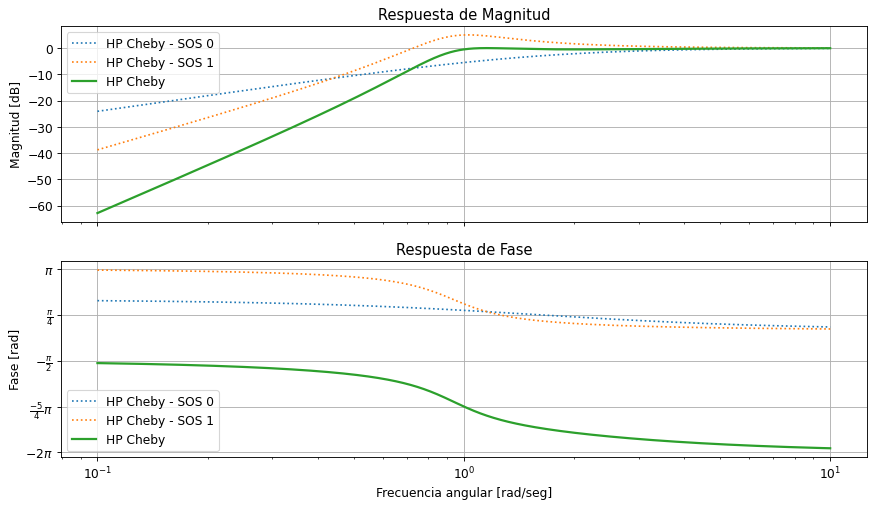

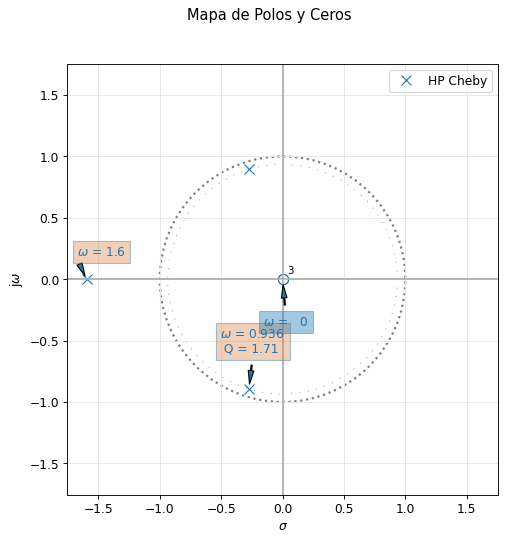

In [6]:
analyze_sys(hp_cheby, 'HP Cheby')

plt.close(4)

- Observando el módulo se puede notar como el filtro cumple con la estructura de un pasa alto al eliminar las bajas frecuencia y posterior de $wp$ el gráfico queda en $0 \space dB$ dejando las altas frecuencias.

- También es apreciable observando el diagrama de polos y ceros que la fase es correcta dado que cuando $w \to 0$ los tres ceros en el origen aporta $90°$ cada uno dando un total de $270° = -90° = -\frac{\pi}{2}$, cuando $w \to \infty$ los ceros aportan $90°$ cada uno mientras que los polos $-90°$ dando una fase total de $0° = -360° = -2\pi$

- Tomar atención a que en el diagrama de polos y ceros, los primeros ya no se encuentran dentro de una misma circunferencia, incluso, con la transferencia normalizada. Esto es debido a que en aproximación Chebyshev las distribución respeta una elipse, de modo que tenemos un par de polos complejos conjugados dentro de la cicunferencia de radio unidad y un polo real fuera de la misma.

- Notar que todos los polos obtenidos se encuentran en el semiplano izquierdo, verificando una vez más la transferencia obtenida.

#### ***Comparación con el filtro pasa bajos prototipo***

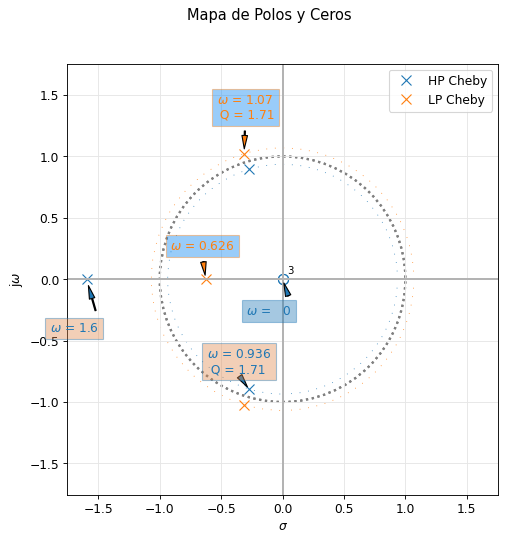

In [8]:
analyze_sys(hp_cheby, 'HP Cheby')
analyze_sys(lp_cheby, 'LP Cheby')

plt.close(1)
plt.close(4)

- Comparando ambos diagramas se pueden oservar similitudes y diferencias. Primeramente, en ninguno de los dos los polos están distribuidos en una circunferencia, con lo cual, ambos respetan la distribución de una elipse, pero de semiejes opuestos en longitud. Es decir, en el pasa bajos el semieje mayor parece esta en dirección al $jw$, mientras que en el pasa altos este se encuentra en la dirección de $\sigma$.
- Por lo tanto el pasa bajos tiene un par de polos complejos conjugados fuera de la circunferencia de radio unidad y un polo real dentro de ella.
- El pasa altos, como se mencionó anteriormente, tiene un par de polos complejos conjugados dentro de la circunferencia de radio unidad y un polo real fuera de ella.
- Parece que los polos de un filtro a otro mantienen su $Q$ dado que no se los ve distribuidos en distintos ángulos, sin embargo, se ve como si su $w$ se hubiera invertido, lo cual tiene sentido debido a la ley de transformación de frecuencia.

### ***Implementación del circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones***

Hasta ahora se obtuvo la transferencia $T_{HP}(s)$ pero sin estar dividida en secciones como para poder ser implementada en un circuito.
Por esta razón se buscaron los polos y ceros del filtro pasa bajos para luego aplicar, nuevamente, la ley de transformación para llegar a los del pasa altos. Para ello se usaron la siguientes fórmulas:

$$
\omega_{0_{k}}^{2} = \sigma_{k}^{2} + \omega_{k}^{2}$$
$$
Q_{k} = \frac{1}{2 \cdot \cos(\operatorname{arctg}(\frac{\omega_{k}}{\sigma_{k}}))}
$$

Siendo:

$$
\sigma_{k}= -\operatorname{senh}(a) \cdot \operatorname{sen}(\frac{2k - 1}{2n} \pi)
$$
$$
\omega_{k}= \operatorname{cosh}(a) \cdot \operatorname{cos}(\frac{2k - 1}{2n} \pi)
$$

$$
a= \frac{1}{n} \cdot \operatorname{senh}^{-1}(\frac{1}{\varepsilon}) 
$$


A partir de esta ecuaciones con $k = 1$ y $k= 2$, se obtuvo:
- Polos Complejos Congujados:
$$ \omega_{0_{1}} = 1.0687$$ 
$$ \sigma_{1} = 1.7062$$

- Polo Real:
$$ \omega_{0_{2}} = 0.6263$$

Estos corresponden a los polos del filtro pasa bajos y viendo nuevamente el diagrama de polos y ceros podes verificar los valores.

Sin embargo necesitamos los correspondientes al filtro pasa altos de modo que se aplica a los $\omega_{0_{k}}$ la tranformación $\frac{1}{w}$, con lo cual:

- Polos Complejos Congujados:
$$ \omega_{0_{1}} = 0.9357$$ 
$$ \sigma_{1} = 1.7062$$

- Polo Real:
$$ \omega_{0_{2}} = 1.5966$$

Los cuales coinciden con los valores del diagrama de polos y ceros.

A partir de estos valores de obtienen las secciones para implementar el filtro, se verificó la transferencia mediante:

In [9]:
print("HP Cheby dividida en secciones")

pretty_print_SOS(hp_cheby)

HP Cheby dividida en secciones


<IPython.core.display.Math object>

#### ***Implementación***

<figure style="text-align:center;">
    <img src="foto_con_inductores.png" width="800">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 2. Implementación con secciones pasivas divididas por un elemento actrivo. a) Circuito RL serie b)Cicuito RLC serie
    </figcaption>
</figure>

- Para la sección de primer orden se hizo uso de un RL con inductor en derivación serie cuya transferencia es:

$$
T(s) = \frac{s}{s + \frac{R}{L}}
$$

Donde se eligio como norma de impedancia $\Omega_{z} = R$, queda la transferencia:
$$
T(s) = \frac{s}{s + \frac{1}{L'}} = \frac{s}{s + 1.596}
$$

Por lo tanto: 
$$ L' = 0.6265$$

- Como sección de segundo orden se tomo un RLC con el inductor en derivación serie de transferencia:
$$
T(s) = \frac{s^{2}}{s^{2} + s \cdot \frac{R}{L} + \frac{1}{LC}}
$$
Tomando nuevamente como norma de impedancia $\Omega_{z} = R$, queda la transferencia:

$$
T(s) = \frac{s^{2}}{s^{2} + s \cdot \frac{1}{L'} + \frac{1}{L'C'}} = \frac{s^{2}}{s^{2} + s \cdot 0.5483 + 0.8753}
$$

Por lo tanto: 
$$ L' =1.8238$$
$$ C' =0.6264$$

#### ***Simulación***

<figure style="text-align:center;">
    <img src="graf_con_inductores.png" width="900">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 3. Gráfico pasa altos implementado con secciones pasivas divididas por un elemento activo
    </figcaption>
</figure>

- Se observa que para $f <= fs$ la atenucación es $\alpha >= \alpha_{min}= 30 \space dB$
- Luega para $f >= fp$ el ripple es $\alpha >= \alpha_{max}= 0.5 \space dB$

Respetando así la plantila dada y obteniendo la forma de un filtro pasa altos.
Y la fase coincide con la obtenidad en incisos anteriores.

### ***Reemplazo de los inductores en las estructuras pasivas mediante el GIC de Antoniou***

<figure style="text-align:center;">
    <img src="gic.png" width="400">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 4. Estructura GIC de Antoniou
    </figcaption>
</figure>

Analizando esta estructura se puede llegar a la siguiente conclusión:

$$ Z_{in} = \frac{Z_{1} \cdot Z_{3} \cdot Z_{5}}{ Z_{2} \cdot Z_{4}} $$

De modo tal que si reemplazo:
$$ Z_{in} = \frac{R_{1} \cdot R_{3} \cdot R_{5}}{ \frac{1}{sC_{2}} \cdot R_{4}} = \frac{R_{1} \cdot R_{3} \cdot R_{5}}{R_{4}}\cdot sC_{2} = s \cdot L_{eq}$$

- Con lo cual en la sección 1 podría tomar: $R = R_{1}=R_{3} = R_{4} = R_{5} = \Omega_{z}$, por lo tanto una vez se normalizó por impedancia:

$$ s \cdot L_{eq} = s \cdot C_{2}'$$
$$ L_{eq} = C_{2}'$$
    Reemplazo por el valor del inductor en el inciso anterior:
$$ C_{2}' = 0.6265$$

- Pot otro lado en la sección aplico la misma logica donde $R = R_{1}=R_{3} = R_{4} = R_{5} = \Omega_{z}$, por lo tanto una vez se normalizó por impedancia:

$$ s \cdot L_{eq} = s \cdot C_{2}'$$
$$ L_{eq} = C_{2}'$$
    Reemplazo por el valor del inductor en el inciso anterior:
$$ C_{2}' = 1.8238$$ 


<figure style="text-align:center;">
    <img src="foto_con_gics.png" width="800">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 5. Implementación de filtro pasa altos reemplazando inductores por la estructura GIC de Antoniou
    </figcaption>
</figure>

#### ***Simulación***

<figure style="text-align:center;">
    <img src="graf_con_gics.png" width="900">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 6. Gráfico de filtro pasa altos reemplazando inductores por la estructura GIC de Antoniou
    </figcaption>
</figure>

Nuevamente se observa:
- Se observa que para $f <= fs$ la atenucación es $\alpha >= \alpha_{min}= 30 \space dB$
- Luega para $f >= fp$ el ripple es $\alpha >= \alpha_{max}= 0.5 \space dB$

Respetando así la plantila dada y obteniendo la forma de un filtro pasa altos.
Y la fase coincide con la obtenidad en incisos anteriores.

### ***Reemplazo la SOS pasiva del punto 3. por la estructura MFB en configuración pasa altos***

<figure style="text-align:center;">
    <img src="mfb.png" width="400">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 7. Estructura Multiple Feedback pasa altos
    </figcaption>
</figure>

Analizando esta estrcutura se llega a la siguiente transferencia:

$$
T(s) = - \frac{s^{2} \cdot \frac{C_3}{C_1}}{s^{2} + s \cdot (\frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2}) + \frac{Y_1 \cdot Y_2}{C_1 \cdot C_2}}
$$

Y como se quiere que la transferencia de segundo orden coincida con:
$$ \frac{s^{2}}{s^{2} + s \cdot 0.5483 + 0.8753}$$

Entonces:

$$ k = \frac{C_2}{C_3} = 1$$
$$ \omega_{0}^{2} =  \frac{Y_1 \cdot Y_2}{C_1 \cdot C_2} = 0.8753 $$
$$\frac{\omega_0}{Q} = \frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2} $$

Por lo tanto operando para que se cumplan las condiciones queda:

$$ C_1 = C_2 = C_3 = 1$$
$$ R_1 = 0.2087$$
$$R_2=5.4734$$

<figure style="text-align:center;">
    <img src="foto_con_mfb.png" width="800">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 8. Implementación de sección de segundo orden con estructura Multiple Feedback pasa altos
    </figcaption>
</figure>

#### ***Simulación***

<figure style="text-align:center;">
    <img src="graf_con_mfb.png" width="900">
    <figcaption style="font-size:0.9em; color:gray;">
        Figura 9. Gráfico de filtro pasa altos con implementación de sección de segundo orden con estructura Multiple Feedback pasa altos
    </figcaption>
</figure>

Nuevamente se observa:
- Se observa que para $f <= fs$ la atenucación es $\alpha >= \alpha_{min}= 30 \space dB$
- Luega para $f >= fp$ el ripple es $\alpha >= \alpha_{max}= 0.5 \space dB$

Respetando así la plantila dada y obteniendo la forma de un filtro pasa altos.
Y la fase coincide con la obtenidad en incisos anteriores.

#### ***Estudio de la sensibilidad***

- En primer lugar se pedía $S^{C_1}_{\omega_0}$ (sensibilidad de $C_1$ respecto de $\omega_0$), donde:

$$
S^{C_1}_{\omega_0} = \frac{\omega_0}{C_1}\cdot \frac{dC_1}{d\omega_0} = \frac{\omega_0}{C_1} \cdot \frac{d(\frac{Y_1 \cdot Y_2}{\omega_0^{2} \cdot C_2})}{d\omega_0} = -2 \cdot \frac{Y_1 \cdot Y_2}{C_1 \cdot C_2} \cdot \omega_0^{-2}
$$

Siendo: $Y_1 = \frac{1}{R_1}$ y $Y_2 = \frac{1}{R_2}$, reemplazando valores queda:

$$S^{C_1}_{\omega_0} = -1.9999$$

- En segundo lugar se pedía $S^{R_1}_{Q}$ (sensibilidad de $R_1$ respecto de $Q$).
Recordando:
$$\frac{\omega_0}{Q} = \frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2} $$

$$ Q= \frac{\omega}{\frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2}}$$

Si reemplazo a $C_1=C_3 = 1$ como se marcó en sus valores anteiores y a $ \omega_{0} = \sqrt{ \frac{Y_1 \cdot Y_2}{C_1 \cdot C_2}}$, se llega a:

$$ Q = \frac{1}{\sqrt{R_1}} \cdot \sqrt{R_2} \cdot \frac{\sqrt{C_1\cdot C_2}}{\frac{2}{C_2} + 1}$$

Con lo cual:
$$ R_1 = \frac{1}{Q^{2}} \cdot R_2 \cdot \frac{C_1\cdot C_2}{(\frac{2}{C_2} + 1)^{2}}$$

Para finalmente:

$$
S^{R_1}_{Q} = \frac{Q}{R_1}\cdot \frac{dR_1}{dQ} = \frac{Q}{R_1} \cdot \frac{d(\frac{1}{Q^{2}} \cdot R_2 \cdot \frac{C_1\cdot C_2}{(\frac{2}{C_2} + 1)^{2}})}{dQ} = -2 \cdot \frac{1}{R_1} \cdot \frac{R_2C_1C_2}{(\frac{2}{C_2} +1)^{2}} \cdot Q^{-2}
$$

Reemplazando valores obtenemos:

$$S^{R_1}_{Q} = -2.00.17$$

- En tercer lugar se pedía $S^{R_2}_{Q}$ (sensibilidad de $R_2$ respecto de $Q$).
Recordando:
$$\frac{\omega_0}{Q} = \frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2} $$

$$ Q= \frac{\omega}{\frac{Y_2}{C_2} + \frac{Y_2}{C1} + \frac{C_3\cdot Y_2}{C_1\cdot C_2}}$$

Si reemplazo a $C_1=C_3 = 1$ como se marcó en sus valores anteiores y a $ \omega_{0} = \sqrt{ \frac{Y_1 \cdot Y_2}{C_1 \cdot C_2}}$, se llega a:

$$ Q = \frac{1}{\sqrt{R_1}} \cdot \sqrt{R_2} \cdot \frac{\sqrt{C_1\cdot C_2}}{\frac{2}{C_2} + 1}$$

Con lo cual:
$$ R_2 = Q^{2} \cdot R_1 \cdot \frac{(\frac{2}{C_2} + 1)^{2}}{C_1\cdot C_2}$$

Para finalmente:

$$
S^{R_2}_{Q} = \frac{Q}{R_2}\cdot \frac{dR_2}{dQ} = \frac{Q}{R_2} \cdot \frac{d(Q^{2} \cdot R_1 \cdot \frac{(\frac{2}{C_2} + 1)^{2}}{C_1\cdot C_2})}{dQ} = 2 \cdot \frac{1}{R_2} \cdot \frac{R_1(\frac{2}{C_2} +1)^{2}}{C_1C_2} \cdot Q^{2}
$$

Reemplazando valores obtenemos:

$$S^{R_2}_{Q} = 1.9982$$

## ***Bonus 1***

### ***¿Podría implementar una red del mismo orden con una aproximación de máxima planicidad?***

El cálculo de $ \varepsilon^{2}$ tanto en máxima planicidad como en Chebyshev es igual, por lo tanto el $ \varepsilon^{2} = 0.1220$ se mantiene.

Haré uso del siguiente código para hayar el orden:

In [18]:
# Inicialización e importación de módulos

# Módulos externos
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti

from pytc2.general import print_subtitle

alpha_max = 0.5 #Ripple de la plantilla en dB

alpha_min= 30 #atenuación de la plantila en dB

eps_2= 10**(alpha_max/10) - 1 #Espsilon cuadrado

w_s=4

#BONUS 1: MAXIMA PLANICIDAD CHEQUEO DE PLANTILLA SI ES POSIBLE

for nn in np.arange(start = 1, stop= 6):
    
    alpha_n = 10* np.log10(1+ (eps_2*w_s**(2*nn)))
    
    print(f'Para n ={nn} el alpha_n es de {alpha_n: 3.3f} dB')
    
    if alpha_n >= alpha_min:
        orden=nn
        break



print(f'Para cumplir con la plantila en Máxima Planicidad se necesita un orden {orden} ya que se obtuvo un alpha_n de {alpha_n: 3.3f} dB que es mayor o igual al alpha_min={alpha_min} dB')


Para n =1 el alpha_n es de  4.702 dB
Para n =2 el alpha_n es de  15.084 dB
Para n =3 el alpha_n es de  26.997 dB
Para n =4 el alpha_n es de  39.030 dB
Para cumplir con la plantila en Máxima Planicidad se necesita un orden 4 ya que se obtuvo un alpha_n de  39.030 dB que es mayor o igual al alpha_min=30 dB


- A partir de este resultando la conclusión es: no, no se puede implementar un filtro de máxima planicidad de orden 3 respetando la plantilla dada.

## ***Bonus 2***

### ***Verifique que el orden obtenido analíticamente, mediante simulación numérica en Python, cumple con el requerimiento de la plantilla.***

A partir del mismo código utilizado en el inciso anterior pero implmentado para buscar el orden en un Chebyshev se obtiene

In [19]:
#Bonus 2 chequeo cheby

print('CHEBYSHEV')

for nn in np.arange(start = 1, stop= 6):
    
   dentro_cosh = nn * np.arccosh(w_s)
   alpha_n = 10 * np.log10(1 + eps_2 * (np.cosh(dentro_cosh)**2))
    
   print(f'Para n ={nn} es alpha_n es de {alpha_n: 3.3f} dB')
    
   if alpha_n >= alpha_min:
        orden=nn
        break



print(f'Para cumplir con la plantila en Chebyshev se necesita un orden {orden} ya que se obtuvo un alpha_n de {alpha_n: 3.3f} dB que es mayor o igual al alpha_min={alpha_min} dB')



CHEBYSHEV
Para n =1 es alpha_n es de  4.702 dB
Para n =2 es alpha_n es de  20.728 dB
Para n =3 es alpha_n es de  38.613 dB
Para cumplir con la plantila en Chebyshev se necesita un orden 3 ya que se obtuvo un alpha_n de  38.613 dB que es mayor o igual al alpha_min=30 dB


- Con el resultado obtenido se realizó la verificación numérica de l orden del filtro diseñado.

## ***Conclusión***

Se logró diseñar, verificar e implementar de distintas formas un filtro pasa altos mediante aproximación de Chebyshev a partir de la plantilla ortorgada, de manera correcta proporcionando las respectivas simulaciones numéricas y ciruitales para ello.